In [1]:
# This allows us to import from all folders one level up from notebooks folder - run 1 time
import sys
from pathlib import Path

print('All paths pre-append')
for i,p in enumerate(sys.path):
    print(f"{i}: {p}")
print('-'*100)

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
print('All paths post-append')
for i,p in enumerate(sys.path):
    print(f"{i}: {p}")


All paths pre-append
0: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python311.zip
1: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python3.11
2: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python3.11/lib-dynload
3: 
4: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python3.11/site-packages
----------------------------------------------------------------------------------------------------
All paths post-append
0: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python311.zip
1: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python3.11
2: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python3.11/lib-dynload
3: 
4: /Users/irabandutta/Developer/2026-06-deep-learning-workbench/.env/dl-basics/lib/python3.11/site-packages
5: /Users/irabandutta/Developer/2026-0

# **Imports**

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.datasets.cifar10 import load_cifar10

# **Load CIFAR10 Dataset**

In [3]:
cv_data_root_path = Path("/Users/irabandutta/Developer/2026-06-deep-learning-workbench/00_foundations/computer_vision/data")
cifar10_path = cv_data_root_path / "cifar10"

X_train, Y_train, X_test, Y_test, label_map = load_cifar10(cifar10_path)

# Change dtype
X_train = X_train.astype(np.float64)
X_test = X_test.astype(np.float64)

print(X_train.shape, X_train.dtype, Y_train.shape)
print(X_test.shape, X_test.dtype, Y_test.shape)

print('-'*50)
for k, v in label_map.items():
    print(f"{k}: {v}")

(50000, 3, 32, 32) float64 (50000,)
(10000, 3, 32, 32) float64 (10000,)
--------------------------------------------------
num_cases_per_batch: 10000
label_names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_vis: 3072


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.0..254.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [7.0..249.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [11.0..218.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [4.0..234.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..222.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB da

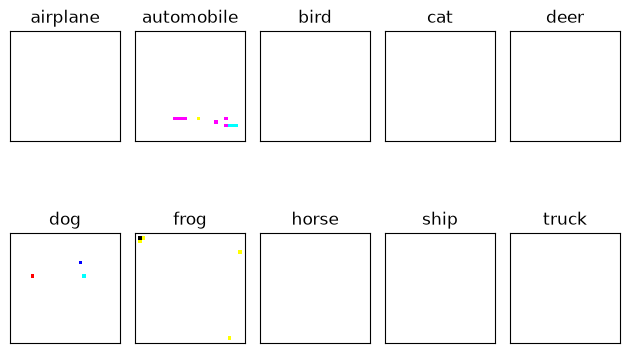

In [4]:
# Viewing 1 image from all classes

fig, ax = plt.subplots(nrows=2, ncols=5)
ax = ax.flatten()

for i, label in enumerate(label_map["label_names"]):
    img = np.transpose(X_train[Y_train==i][0], axes=(1, 2, 0))
    ax[i].imshow(img)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(label)

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [11.0..218.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [25.0..225.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2.0..218.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.0..239.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [28.0..251.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB 

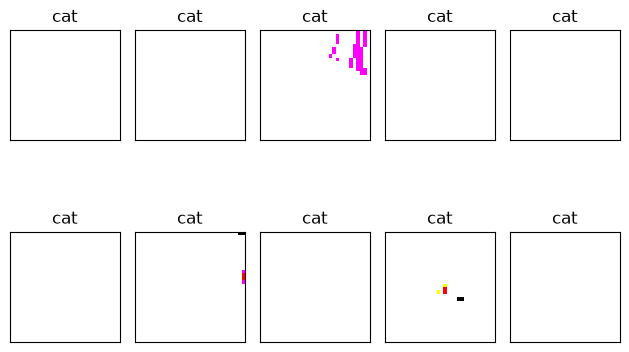

In [5]:
# View 10 images from 1 class
fig, ax = plt.subplots(nrows=2, ncols=5)
ax = ax.flatten()

for i in range(10):
    label_idx = 3
    label = label_map["label_names"][label_idx]
    img = np.transpose(X_train[Y_train==label_idx][i], axes=(1, 2, 0))
    ax[i].imshow(img)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(label)

plt.tight_layout()
plt.show()

# **Split Data**

In [6]:
np.random.seed(42)

# Train and Validation Set
num_train_samples = 49000
all_idxs = np.arange(X_train.shape[0])
train_idxs = np.random.choice(X_train.shape[0], size=num_train_samples, replace=False)
mask_train_idxs = np.ones(X_train.shape[0], dtype=np.bool)
mask_train_idxs[train_idxs]=False
val_idxs = all_idxs[mask_train_idxs]

# Dev Set: Random sample from train set for quick testing
num_dev_samples = 1000
dev_idxs = np.random.choice(train_idxs, size=num_dev_samples, replace=False)

X_tr, Y_tr = X_train[train_idxs], Y_train[train_idxs]
X_val, Y_val = X_train[val_idxs], Y_train[val_idxs]
X_dev, Y_dev = X_train[dev_idxs], Y_train[dev_idxs]
X_ts, Y_ts = X_test, Y_test

# Flatten
X_tr = X_tr.reshape(num_train_samples, -1)
X_val = X_val.reshape((X_train.shape[0]-num_train_samples), -1)
X_dev = X_dev.reshape(num_dev_samples, -1)
X_ts = X_ts.reshape(X_test.shape[0], -1)



print('Train:', X_tr.shape, Y_tr.shape)
print('Validation:', X_val.shape, Y_val.shape)
print('Dev-For quick test:', X_dev.shape, Y_dev.shape)
print('Test:', X_ts.shape, Y_ts.shape)


Train: (49000, 3072) (49000,)
Validation: (1000, 3072) (1000,)
Dev-For quick test: (1000, 3072) (1000,)
Test: (10000, 3072) (10000,)


# **Mean Image Subtraction**

## **What is the Mean Image?**

The **mean image** is obtained by averaging every pixel across all training images.

```python
mean_image = np.mean(X_train, axis=0)
```

It has the same shape as a single image (`3 x 32 × 32` for CIFAR-10).

---

## **Why subtract the mean image?**

```python
X_train -= mean_image
X_val   -= mean_image
X_test  -= mean_image
```

Subtracting the mean image **centers the data around zero**, so that each pixel represents its **deviation from the average training image** rather than its absolute intensity.

This has several advantages:

- Removes the common background/brightness shared by most images.
- Helps the model focus on discriminative features (edges, shapes, textures).
- Produces better-conditioned data, leading to faster and more stable gradient descent.
- Reduces the burden on the bias term, since the input features now have approximately zero mean.

---

## **Important Note**

The mean image **must be computed only from the training set**:

```python
mean_image = np.mean(X_train, axis=0)
```

The same mean image is then used to normalize the validation, test, and development sets.

Computing separate means for the validation or test sets would introduce **data leakage**.

In [7]:
mean_image = X_tr.mean(axis=0)
print('mean_image.shape:', mean_image.shape)

# Inplace
# X_tr  -= mean_image
# X_val -= mean_image
# X_dev -= mean_image
# X_ts  -= mean_image

# Creates seperate memory lcoation
X_tr  = X_tr - mean_image
X_val = X_val - mean_image
X_dev = X_dev - mean_image
X_ts  = X_ts - mean_image

mean_image.shape: (3072,)
